# Portuguese term deposit ML project 

In [10]:
!pip install scikit-learn

In [11]:
import pandas as pd
import sklearn 
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',40)

## Load data into Python environment

In [13]:
df1=pd.read_excel('TermDeposit1.xlsx')
df1.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Verify if data is loaded as expected

In [15]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [16]:
df1.shape

(45211, 17)

# Data Cleaning

### Missing value analysis

In [19]:
df1.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [20]:
df1.duplicated().sum()

0

> no missing and duplicate found

# Outlier analysis

In [23]:
# * Features to be analysed:
# > age
# > balance
# > duration
# > campaign
# > pdays
# > previous

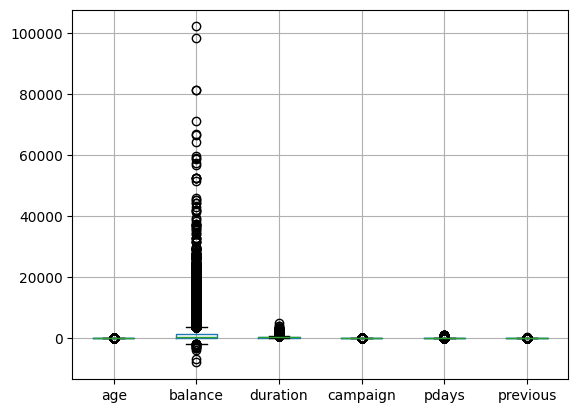

In [24]:
df1[['age','balance','duration','campaign','pdays','previous']].boxplot()
plt.show()

> analysis: all the target cols have outliers individually

# Creating a function to perform outlier analysis using boxplot method

In [27]:
def analyse_outliers(data, colname):

    # Boxplot Method 
    Q1 = data[colname].quantile(0.25)
    Q3 = data[colname].quantile(0.75)
    
    IQR = Q3 - Q1
    
    LL = Q1 - 1.5 * IQR
    UL = Q3 + 1.5 * IQR
    
    ul_outlier_count = data[data[colname] > UL].shape[0]
    ll_outlier_count = data[data[colname] < LL].shape[0]
    
    total_outlier_count = ul_outlier_count + ll_outlier_count
    
    outlier_percentage = round(total_outlier_count / data.shape[0] * 100,2)

    print(f'Q1: {Q1} | Q3: {Q3} | IQR: {IQR} | LL: {LL} | UL: {UL}')
    print(f'UL Count: {ul_outlier_count} | LL Count: {ll_outlier_count} | Total: {total_outlier_count} outliers | Total%: {outlier_percentage}% ')
    return LL, UL

#### age

Q1: 33.0 | Q3: 48.0 | IQR: 15.0 | LL: 10.5 | UL: 70.5
UL Count: 487 | LL Count: 0 | Total: 487 outliers | Total%: 1.08% 


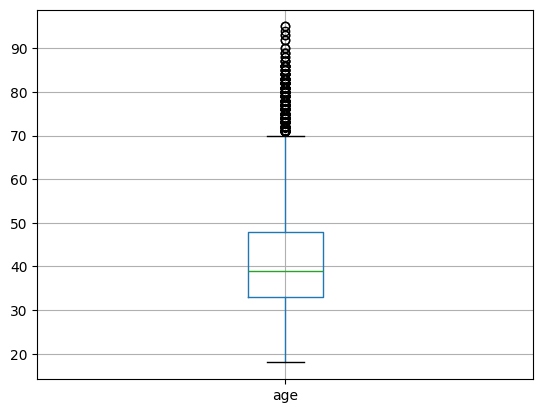

In [29]:
df1[['age']].boxplot()
LL_age,UL_age = analyse_outliers (df1, 'age')
plt.show()

> Analysis : since we have < 5% as outliers, we can replace with UL (uppper limit)

In [31]:
# # Boxplot Method 
# Q1 = df1['age'].quantile(0.25)
# Q3 = df1['age'].quantile(0.75)

# IQR = Q3 - Q1

# LL = Q1 - 1.5 * IQR
# UL = Q3 + 1.5 * IQR

# print(f'Q1: {Q1} | Q3: {Q3} | IQR: {IQR} | LL: {LL} | UL: {UL}')

In [32]:
# ul_outlier_count = df1[df1['age'] > UL].shape[0]
# ll_outlier_count = df1[df1['age'] < LL].shape[0]

# total_outlier_count = ul_outlier_count + ll_outlier_count

# outlier_percentage = round(total_outlier_count / df1.shape[0] * 100,2)

# print(f'UL Count: {ul_outlier_count} | LL Count: {ll_outlier_count} | Totoal: {total_outlier_count} | Total%: {outlier_percentage}% | ')

In [33]:
#analyse_outliers(df1,'age')

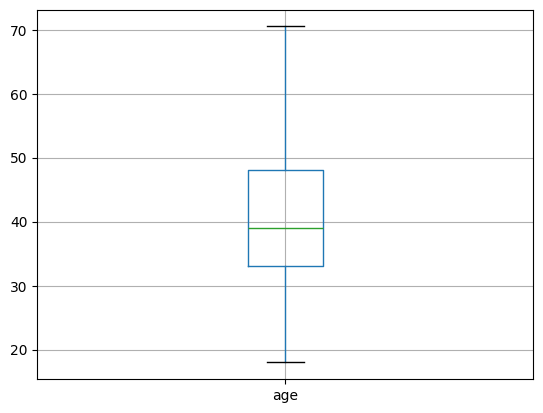

In [34]:
df1.loc[df1['age'] > UL_age,'age' ] = UL_age
df1[['age']].boxplot()
plt.show()

Q1: 72.0 | Q3: 1428.0 | IQR: 1356.0 | LL: -1962.0 | UL: 3462.0
UL Count: 4712 | LL Count: 17 | Total: 4729 outliers | Total%: 10.46% 


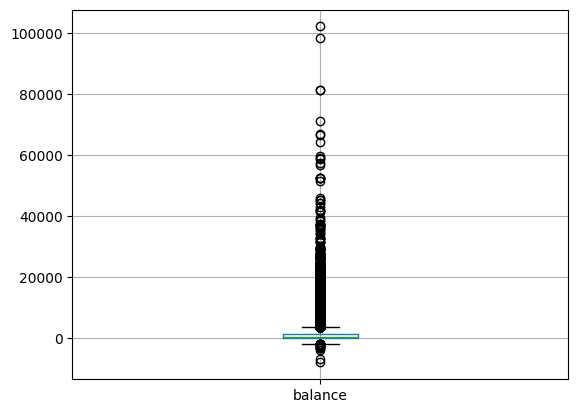

In [35]:
df1[['balance']].boxplot()
analyse_outliers(df1,'balance')
plt.show()

In [36]:
# > analysis: Two options when >10% outliers
#     . Remove the col(we are doing this)
#     . split the data into two parts - with and without outliers(can do if we do not get desired accuracy)
#         - Before we remove the col, we can perform a transformation - Negative , Low , Moderate , High.
#             In the transformation section we will take this col again

Q1: 103.0 | Q3: 319.0 | IQR: 216.0 | LL: -221.0 | UL: 643.0
UL Count: 3235 | LL Count: 0 | Total: 3235 outliers | Total%: 7.16% 


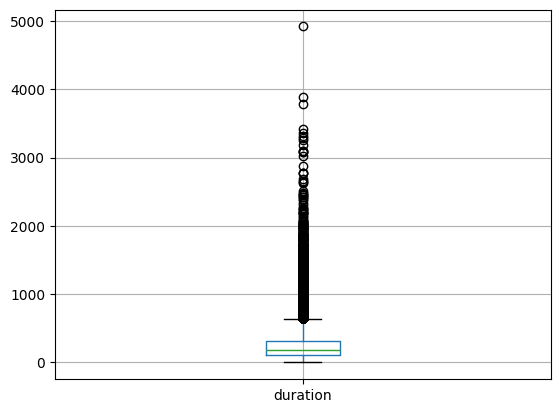

In [37]:
df1[['duration']].boxplot()
LL_duration, UL_duration = analyse_outliers(df1,'duration')
plt.show()

> Analysisi: Since , it our choice when outliers are between 5% - 10% and 7.2% is closer to 5%, we can choose to replace with the upper limit  

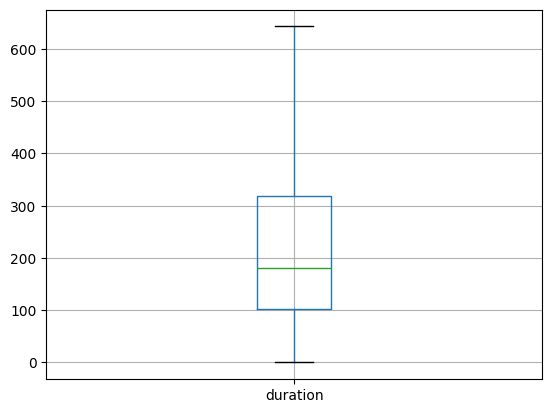

In [39]:
df1.loc[df1['duration']> UL_duration,'duration'] = UL_duration
df1[['duration']].boxplot()
plt.show()

Q1: 1.0 | Q3: 3.0 | IQR: 2.0 | LL: -2.0 | UL: 6.0
UL Count: 3064 | LL Count: 0 | Total: 3064 outliers | Total%: 6.78% 


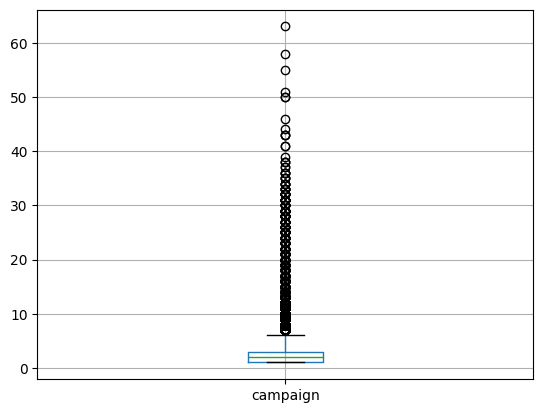

In [40]:
df1[['campaign']].boxplot()
LL_campaign, UL_campaign = analyse_outliers(df1,'campaign')
plt.show()

> Analysis:  Having values like >600 calls from a term deposite campaign is not a vaiable value. 
seems to some discrepancy in data collection. Hence we cab replace the outlier value with the upper limit.'

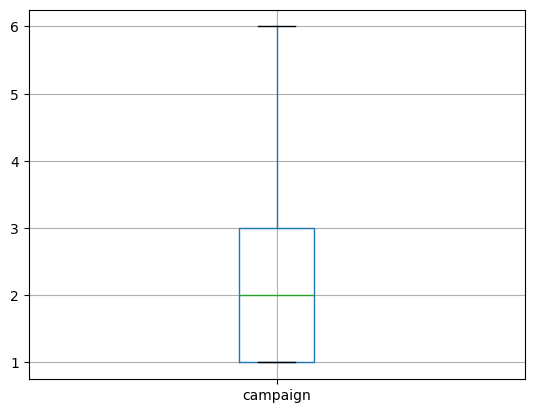

In [42]:
df1.loc[df1['campaign'] > UL_campaign,'campaign'] = UL_campaign
df1[['campaign']].boxplot()
plt.show()

Q1: -1.0 | Q3: -1.0 | IQR: 0.0 | LL: -1.0 | UL: -1.0
UL Count: 8257 | LL Count: 0 | Total: 8257 outliers | Total%: 18.26% 


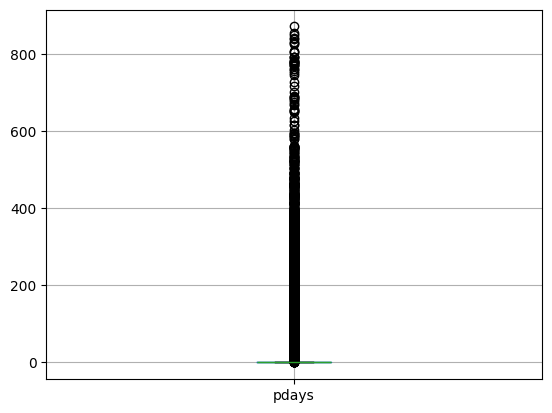

In [43]:
df1[['pdays']].boxplot()
LL_pdays, UL_pdays = analyse_outliers(df1,'pdays')
plt.show()

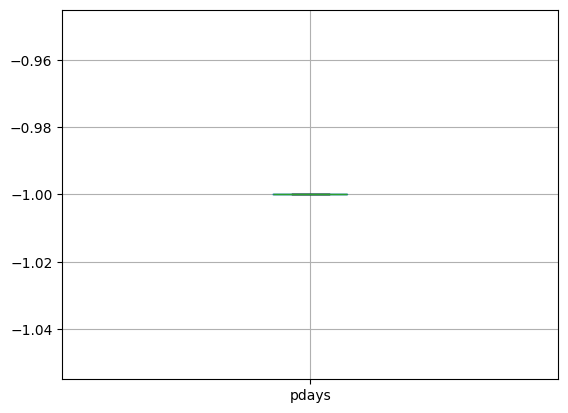

In [44]:
df1.loc[df1['pdays'] > UL_pdays,'pdays'] = UL_pdays
df1[['pdays']].boxplot()
plt.show()

> 'Analysis : Since there is 16%  replacing is not an option as it will introduce bias also cant use it in  numeric form due to so many outliers. 
    Hence the only option left is to convert var - eg. New customer , <1 month, <6 month, <1 year, >1 year 

>  Before we remove the col, we can perform a transformation - Negative , Low , Moderate , High.
      In the transformation section we will take this col again

Q1: 0.0 | Q3: 0.0 | IQR: 0.0 | LL: 0.0 | UL: 0.0
UL Count: 8257 | LL Count: 0 | Total: 8257 outliers | Total%: 18.26% 


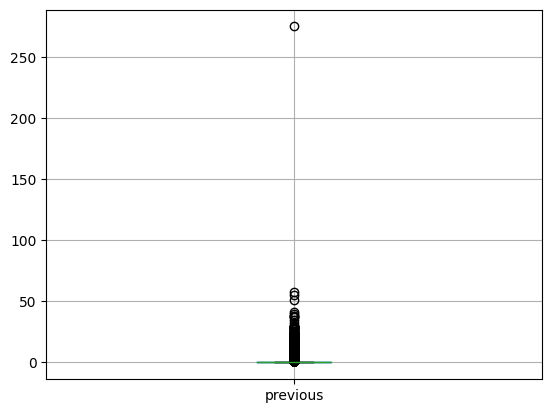

In [47]:
df1[['previous']].boxplot()
LL_previous, UL_previous = analyse_outliers(df1,'previous')
plt.show()

> Analysis: Almost 19% of the data is being shown as outliers using the boxplot method hence we need to chnage the method of detection to mean method

In [49]:
import numpy as np

In [50]:
# Z- method/ Six sigma method/ Mean method 
mean_previous =  np.mean(df1.previous)
std_previous = np.std(df1.previous)
LL_previous = mean_previous - (3 * std_previous)
UL_previous = mean_previous + (3 * std_previous)
print(f'Mean: {mean_previous} | standard Deviation: {std_previous} | LL: {LL_previous}  | UL: {UL_previous}')


Mean: 0.5803233726305546 | standard Deviation: 2.3034155704475343 | LL: -6.329923338712049  | UL: 7.490570083973158


In [51]:
ul_outlier_count = df1[df1['previous'] > UL_previous].shape[0]
ll_outlier_count = df1[df1['previous'] < LL_previous].shape[0]

total_outlier_count = ul_outlier_count + ll_outlier_count

outlier_percentage = round(total_outlier_count / df1.shape[0] * 100,2)

print(f'UL Count: {ul_outlier_count} | LL Count: {ll_outlier_count} | Total: {total_outlier_count} | Total%: {outlier_percentage}% | ')

UL Count: 582 | LL Count: 0 | Total: 582 | Total%: 1.29% | 


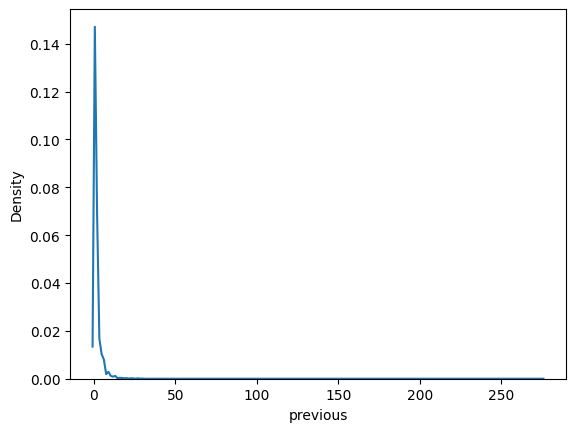

In [52]:
sns.kdeplot(df1['previous'])
plt.show()

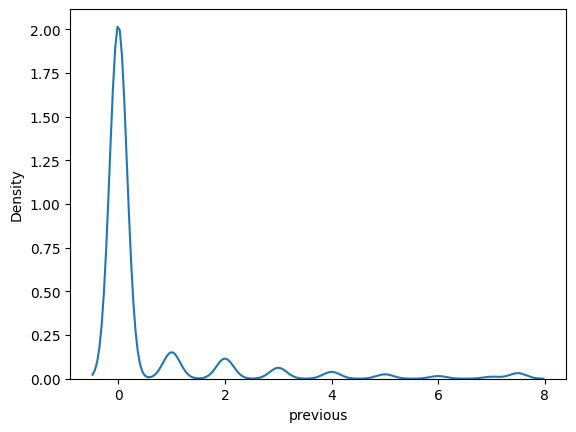

In [53]:
df1.loc[df1['previous']> UL_previous,'previous'] = UL_previous
sns.kdeplot(df1['previous'])
plt.show()

# EDA - Exploratory Data Analysis

In [55]:
df1.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0.0,unknown,no
1,44.0,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0.0,unknown,no


In [ ]:
# # Total customers
# total_customers = len(df1)

# # Subscription rate 
# subscription_rate = (df1['y'].value_counts().get('yes', 0) / total_customers) * 100

# # Loans rate
# house_loan_rate = (df1['housing'].value_counts().get('yes', 0 ) / total_customers) *100
# personal_loan_rate = (df1['loan'].value_counts().get('yes' , 0 )/ total_customers) * 100

# # Deafult credit rates
# default_credit_rates = (df1['default'].value_counts().get('yes', 0 )/ total_customers) *100

# # duration matrics
# avg_duration = df1['duration'].mean()
# max_duration = df1['duration'].max()

# # Average balance
# avg_balance = df1['balance'].mean()

# # campaign efficiency
# average_contacts = df1['campaign'].mean()
# contacted_more_than_one = (df1['campaign'] > 1).sum()
# percentage_contacted_more_than_one = (contacted_more_than_one /total_customers) *100


# # Display KPIs
# print("Key Performance Indicators: ")

# print(f"Total Customers : {total_customers}")
# print(f"Subscription Rate : {subscription_rate:.2f} % ")
# print(f"Housing Loan Rate  : {house_loan_rate:.2f} % ")
# print(f"Personal Loan Rate : {personal_loan_rate:.2f} %")
# print(f"Deafult Credit Rates : {default_credit_rates:.2f} %")
# print(f"Avg Call Duration : {avg_duration:.2f} seconds")
# print(f"Max Call Duration : {max_duration:.2f} seconds")
# print(f"Average Balance : {avg_balance:.2f}")
# print(f"Average Contacts Per Person : {average_contacts:.2f}")
# print(f"Percentage Contacted More Than One : {percentage_contacted_more_than_one}")

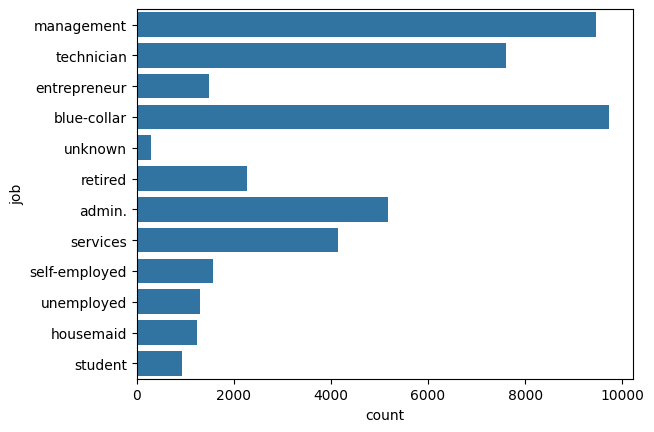

In [56]:
sns.countplot(df1['job'])
plt.show()

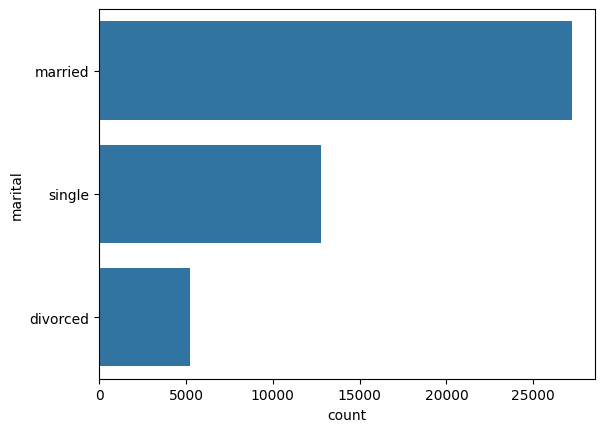

In [57]:
sns.countplot(df1['marital'])
plt.show()


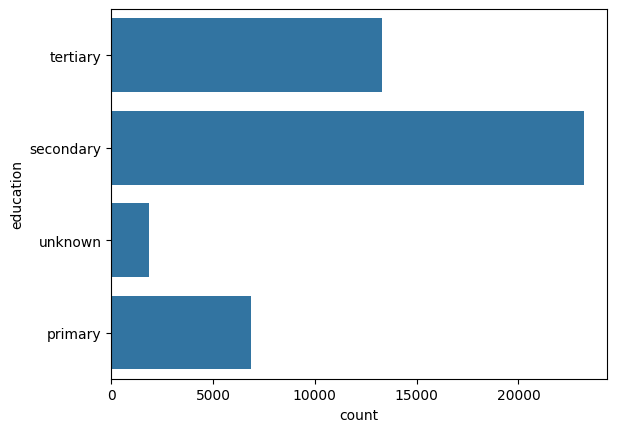

In [58]:
sns.countplot(df1['education'])
plt.show()

In [59]:
# ######### need to be checked   

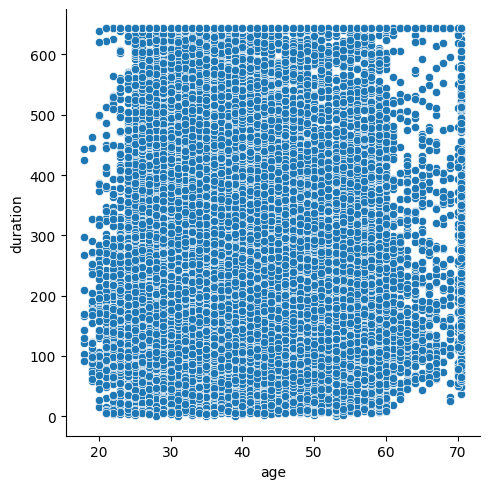

In [60]:
sns.relplot(x='age',y='duration',data=df1)
plt.show()

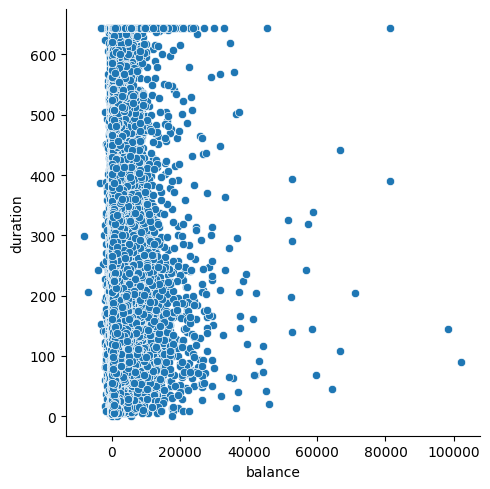

In [61]:
sns.relplot(x='balance',y='duration',data=df1)
plt.show()

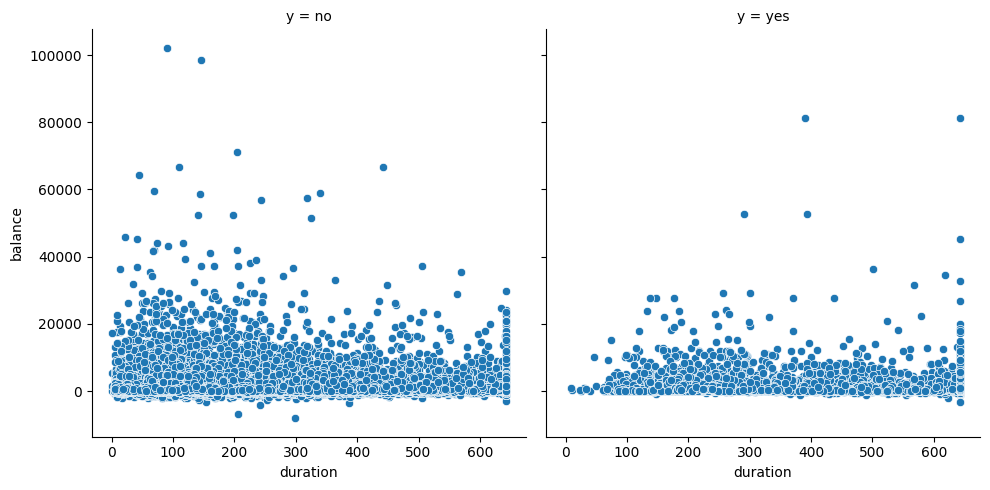

In [62]:
sns.relplot(x='duration',y='balance',col='y', data=df1)
plt.show()

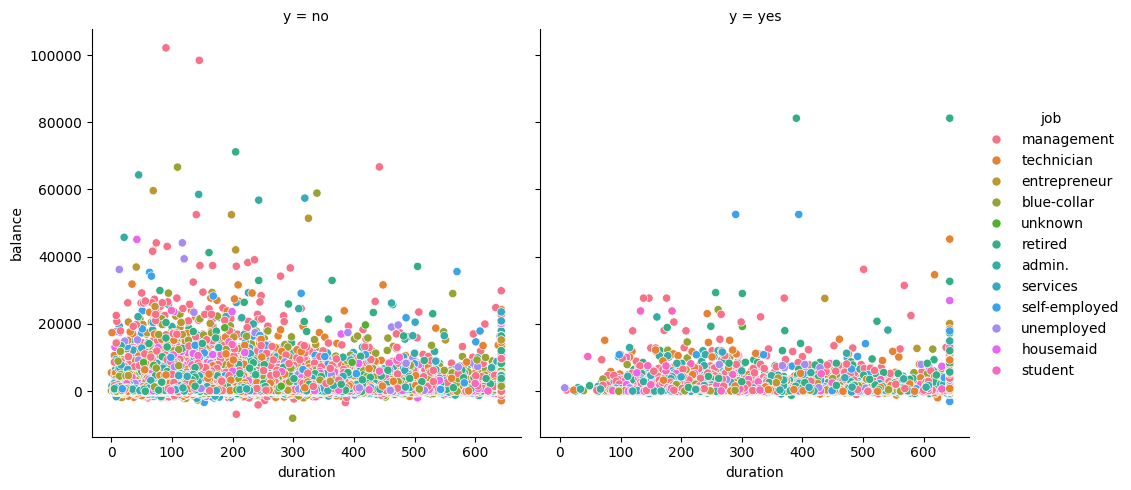

In [63]:
sns.relplot(x='duration',y='balance',col='y',hue='job',data=df1)
plt.show()

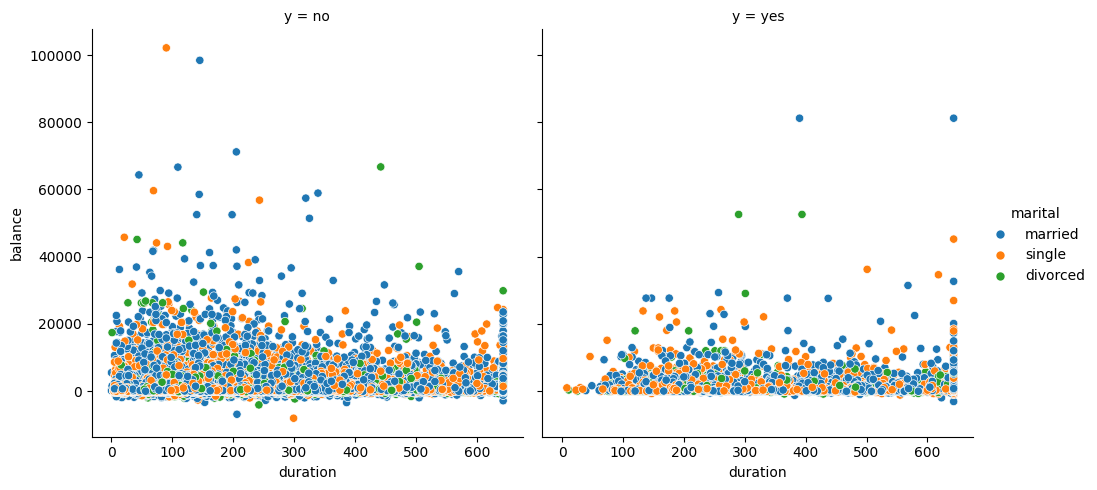

In [64]:
sns.relplot(x='duration',y='balance',col='y',hue='marital',data=df1)
plt.show()

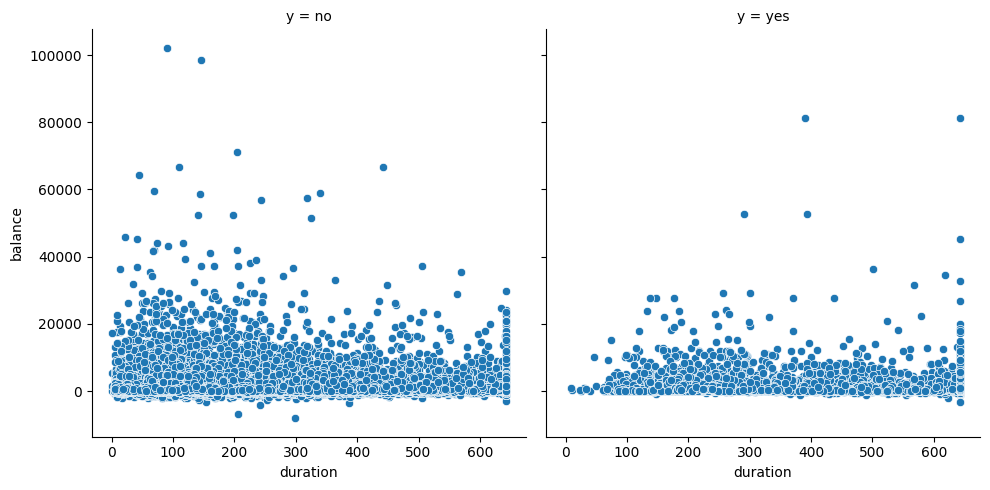

In [65]:
sns.relplot(x='duration',y='balance',col='y',data=df1)
plt.show()

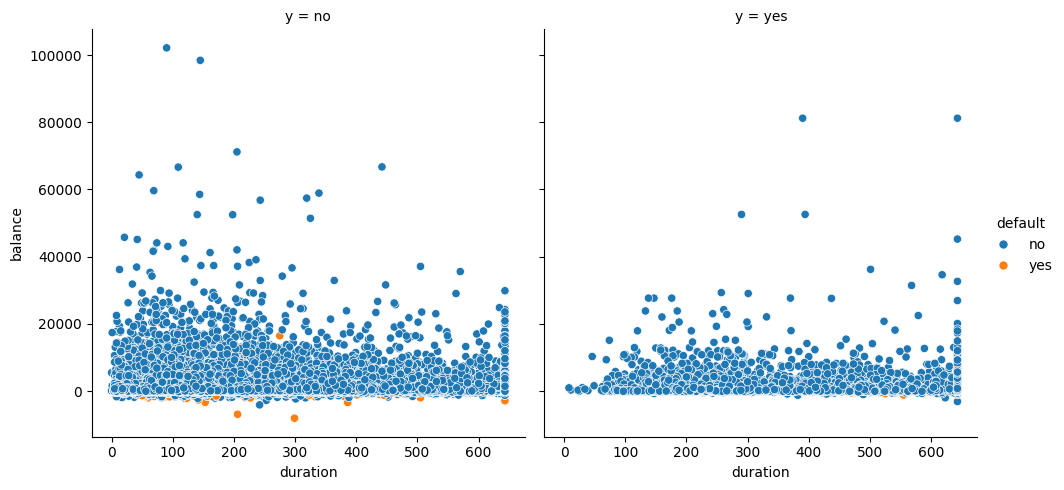

In [66]:
sns.relplot(x='duration',y='balance',col='y',hue='default',data=df1)
plt.show()

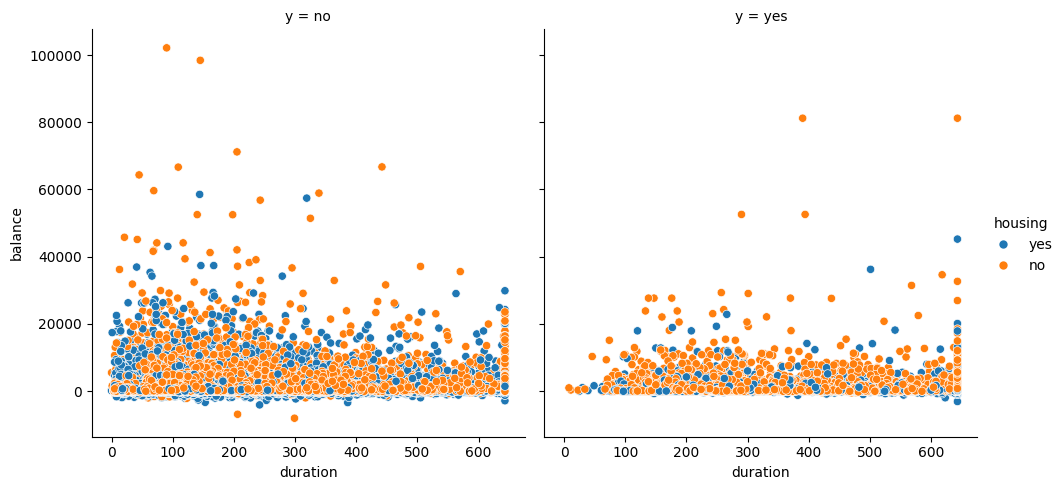

In [67]:
sns.relplot(x='duration',y='balance',col='y',hue='housing',data=df1)
plt.show()

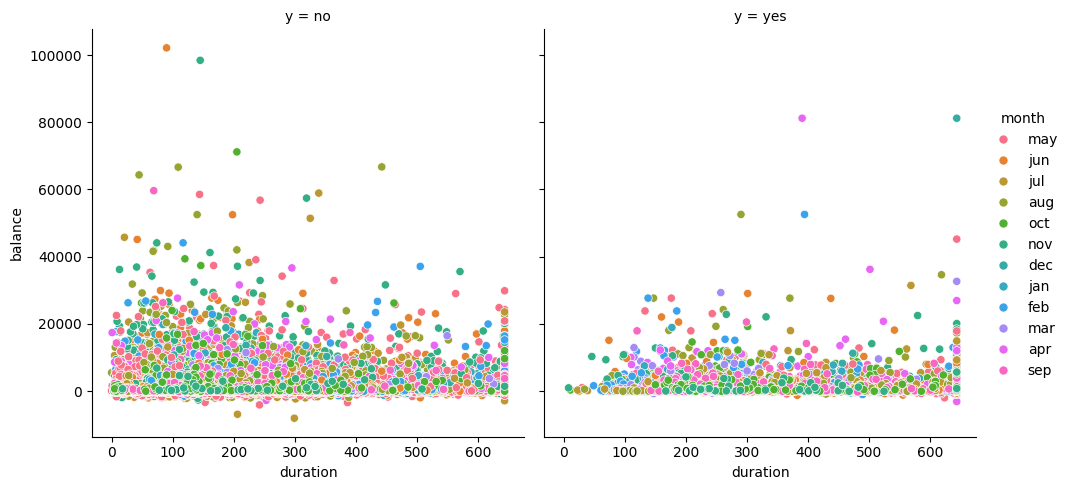

In [68]:
sns.relplot(x='duration',y='balance',col='y',hue='month',data=df1)
plt.show()

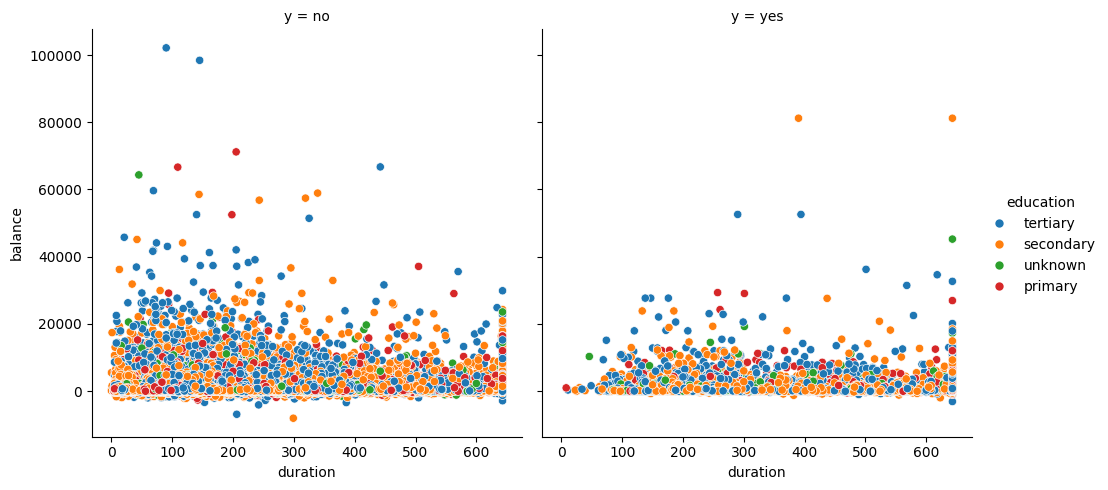

In [69]:
sns.relplot(x='duration',y='balance',col='y',hue='education',data=df1)
plt.show()

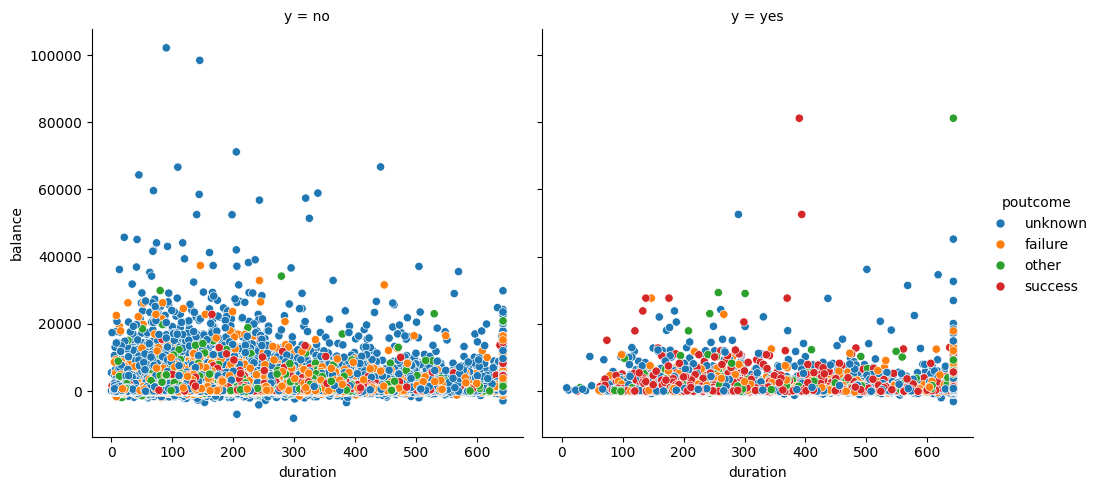

In [70]:
sns.relplot(x='duration',y='balance',col='y',hue='poutcome',data=df1)
plt.show()

# Split Features and target

In [72]:
target = df1['y'].copy()
del df1['y']

In [73]:
target.head()

0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object

In [74]:
df1.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58.0,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0.0,unknown
1,44.0,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0.0,unknown
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0.0,unknown
3,47.0,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0.0,unknown
4,33.0,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0.0,unknown


# Split data into test and train

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
xtrain,xtest, ytrain,ytest = train_test_split(df1,target,test_size=0.2,random_state=234)

# Machine Learning

## Random Forest

In [80]:
# need to be added from my side
xtrain = pd.get_dummies(xtrain)
xtest = pd.get_dummies(xtest)

# Make sure both sets have same columns
xtrain, xtest = xtrain.align(xtest, join='left', axis=1, fill_value=0)


In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
rfm = RandomForestClassifier(n_estimators=500)

In [83]:
rfm.fit(xtrain,ytrain)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
y_pred_rf = rfm.predict(xtest)

In [85]:
from sklearn.metrics import classification_report

In [86]:
print(classification_report(ytest,y_pred_rf))

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7986
         yes       0.65      0.38      0.48      1057

    accuracy                           0.90      9043
   macro avg       0.78      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043



In [87]:
# SVM 

In [88]:
from sklearn.svm import SVC

In [89]:
svc = SVC()

In [90]:
svc.fit(xtrain,ytrain)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [91]:
y_pred_svm = svc.predict(xtest)

In [92]:
print(classification_report(ytest,y_pred_svm))

              precision    recall  f1-score   support

          no       0.88      1.00      0.94      7986
         yes       0.00      0.00      0.00      1057

    accuracy                           0.88      9043
   macro avg       0.44      0.50      0.47      9043
weighted avg       0.78      0.88      0.83      9043



In [93]:
# KNN 

In [94]:
# from sklearn.neighbors import KNeighborsClassifier
# k_value = int(df1.shape[0] / 2)   # Convert to int
# knn = KNeighborsClassifier(n_neighbors=k_value)
# knn.fit(xtrain, ytrain)

In [95]:
from sklearn.neighbors import KNeighborsClassifier

In [96]:
# needs to be added
k_value = int(df1.shape[0] / 2)   # Convert to int

In [97]:
#needs to be changed from.... to......
#knn = KNeighborsClassifier(n_neighbors= (df1.shape[0]/2))
knn = KNeighborsClassifier(n_neighbors=k_value)


In [98]:
knn.fit(xtrain,ytrain)

,n_neighbors,22605
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [99]:
y_pred_knn = knn.predict(xtest)

In [100]:
print(classification_report(ytest,y_pred_rf))

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7986
         yes       0.65      0.38      0.48      1057

    accuracy                           0.90      9043
   macro avg       0.78      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043



# XGBoost

In [102]:
! pip install xgboost

In [103]:
from xgboost import XGBClassifier

In [104]:
from sklearn.ensemble import GradientBoostingClassifier

In [105]:
gbm = GradientBoostingClassifier(n_estimators=500)

In [106]:
gbm.fit(xtrain,ytrain)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,500
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [107]:
y_pred_gb = gbm.predict(xtest)

In [108]:
print(classification_report(ytest,y_pred_gb))

              precision    recall  f1-score   support

          no       0.93      0.97      0.95      7986
         yes       0.65      0.46      0.54      1057

    accuracy                           0.91      9043
   macro avg       0.79      0.71      0.74      9043
weighted avg       0.90      0.91      0.90      9043



In [109]:
print(classification_report(ytest,y_pred_rf))

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      7986
         yes       0.65      0.38      0.48      1057

    accuracy                           0.90      9043
   macro avg       0.78      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043



# Data Transformation

In [111]:
df1.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58.0,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0.0,unknown
1,44.0,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0.0,unknown
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0.0,unknown
3,47.0,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0.0,unknown
4,33.0,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0.0,unknown


# Convert Binary cols to 0s and 1s

In [113]:
# need to add fillna(0) from my side 
df1['default']= df1['default'].map({"yes":1, "no":0}).fillna(0).astype('int')     
df1['housing']= df1['housing'].map({"yes":1, "no":0}).fillna(0).astype('int')
df1['loan']= df1['loan'].map({"yes":1, "no":0}).fillna(0).astype('int')
df1['y']= df1['y'].map({"yes":1, "no":0}).fillna(0).astype('int')

KeyError: 'y'

In [114]:
df1.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58.0,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0.0,unknown
1,44.0,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0.0,unknown
2,33.0,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0.0,unknown
3,47.0,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0.0,unknown
4,33.0,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0.0,unknown


## Converting Nominal cols using one-hot encoding

In [116]:
df1['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [118]:
job_dummies = pd.get_dummies(df1['job']).astype('int')
job_dummies.head()

,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1


In [120]:
job_dummies.iloc[:,:-1]

,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed
0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
45206,0,0,0,0,0,0,0,0,0,1,0
45207,0,0,0,0,0,1,0,0,0,0,0
45208,0,0,0,0,0,1,0,0,0,0,0
45209,0,1,0,0,0,0,0,0,0,0,0


In [122]:
pd.concat([df1,job_dummies.iloc[:,:-1]],axis=1)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed
0,58.0,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0.00000,unknown,0,0,0,0,1,0,0,0,0,0,0
1,44.0,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0.00000,unknown,0,0,0,0,0,0,0,0,0,1,0
2,33.0,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0.00000,unknown,0,0,1,0,0,0,0,0,0,0,0
3,47.0,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0.00000,unknown,0,1,0,0,0,0,0,0,0,0,0
4,33.0,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0.00000,unknown,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,technician,married,tertiary,0,825,0,0,cellular,17,nov,643,3,-1,0.00000,unknown,0,0,0,0,0,0,0,0,0,1,0
45207,70.5,retired,divorced,primary,0,1729,0,0,cellular,17,nov,456,2,-1,0.00000,unknown,0,0,0,0,0,1,0,0,0,0,0
45208,70.5,retired,married,secondary,0,5715,0,0,cellular,17,nov,643,5,-1,3.00000,success,0,0,0,0,0,1,0,0,0,0,0
45209,57.0,blue-collar,married,secondary,0,668,0,0,telephone,17,nov,508,4,-1,0.00000,unknown,0,1,0,0,0,0,0,0,0,0,0


In [124]:
df1 = pd.concat([df1,job_dummies.iloc[:,:-1]],axis=1)

In [126]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            45211 non-null  float64
 1   job            45211 non-null  object 
 2   marital        45211 non-null  object 
 3   education      45211 non-null  object 
 4   default        45211 non-null  int32  
 5   balance        45211 non-null  int64  
 6   housing        45211 non-null  int32  
 7   loan           45211 non-null  int32  
 8   contact        45211 non-null  object 
 9   day            45211 non-null  int64  
 10  month          45211 non-null  object 
 11  duration       45211 non-null  int64  
 12  campaign       45211 non-null  int64  
 13  pdays          45211 non-null  int64  
 14  previous       45211 non-null  float64
 15  poutcome       45211 non-null  object 
 16  admin.         45211 non-null  int32  
 17  blue-collar    45211 non-null  int32  
 18  entrep

In [128]:
del df1['job']

In [130]:
df1.head()

,age,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed
0,58.0,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0.0,unknown,0,0,0,0,1,0,0,0,0,0,0
1,44.0,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,1,0
2,33.0,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0.0,unknown,0,0,1,0,0,0,0,0,0,0,0
3,47.0,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0.0,unknown,0,1,0,0,0,0,0,0,0,0,0
4,33.0,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,0,0


In [132]:
df1['marital'].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [134]:
marital_dummies= pd.get_dummies(df1['marital']).astype('int')
marital_dummies.head()

,divorced,married,single
0,0,1,0
1,0,0,1
2,0,1,0
3,0,1,0
4,0,0,1


In [136]:
marital_dummies.iloc[:,1:]

,married,single
0,1,0
1,0,1
2,1,0
3,1,0
4,0,1
...,...,...
45206,1,0
45207,0,0
45208,1,0
45209,1,0


In [138]:
df1 = pd.concat([df1,marital_dummies.iloc[:,1:]],axis=1)
df1.head()

,age,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single
0,58.0,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0.0,unknown,0,0,0,0,1,0,0,0,0,0,0,1,0
1,44.0,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,1,0,0,1
2,33.0,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0.0,unknown,0,0,1,0,0,0,0,0,0,0,0,1,0
3,47.0,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0.0,unknown,0,1,0,0,0,0,0,0,0,0,0,1,0
4,33.0,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,0,0,0,1


In [140]:
del df1['marital']
df1.head()

,age,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single
0,58.0,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0.0,unknown,0,0,0,0,1,0,0,0,0,0,0,1,0
1,44.0,secondary,0,29,1,0,unknown,5,may,151,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,1,0,0,1
2,33.0,secondary,0,2,1,1,unknown,5,may,76,1,-1,0.0,unknown,0,0,1,0,0,0,0,0,0,0,0,1,0
3,47.0,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0.0,unknown,0,1,0,0,0,0,0,0,0,0,0,1,0
4,33.0,unknown,0,1,0,0,unknown,5,may,198,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,0,0,0,1


In [142]:
contact_dummies= pd.get_dummies(df1['contact']).astype('int')
contact_dummies.head()

,cellular,telephone,unknown
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1


In [144]:
df1 = pd.concat([df1,contact_dummies.iloc[:,:-1]],axis=1)
del df1['contact']
df1.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single,cellular,telephone
0,58.0,tertiary,0,2143,1,0,5,may,261,1,-1,0.0,unknown,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
1,44.0,secondary,0,29,1,0,5,may,151,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
2,33.0,secondary,0,2,1,1,5,may,76,1,-1,0.0,unknown,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
3,47.0,unknown,0,1506,1,0,5,may,92,1,-1,0.0,unknown,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
4,33.0,unknown,0,1,0,0,5,may,198,1,-1,0.0,unknown,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [146]:
poutcome_dummies= pd.get_dummies(df1['poutcome']).astype('int')
poutcome_dummies.head()

,failure,other,success,unknown
0,0,0,0,1
1,0,0,0,1
2,0,0,0,1
3,0,0,0,1
4,0,0,0,1


In [148]:
df1 = pd.concat([df1,poutcome_dummies.iloc[:,:-1]],axis=1)
del df1['poutcome']
df1.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single,cellular,telephone,failure,other,success
0,58.0,tertiary,0,2143,1,0,5,may,261,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
1,44.0,secondary,0,29,1,0,5,may,151,1,-1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
2,33.0,secondary,0,2,1,1,5,may,76,1,-1,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,47.0,unknown,0,1506,1,0,5,may,92,1,-1,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,33.0,unknown,0,1,0,0,5,may,198,1,-1,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


## Convert Ordinal into Numeric

In [151]:
df1.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single,cellular,telephone,failure,other,success
0,58.0,tertiary,0,2143,1,0,5,may,261,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
1,44.0,secondary,0,29,1,0,5,may,151,1,-1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
2,33.0,secondary,0,2,1,1,5,may,76,1,-1,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,47.0,unknown,0,1506,1,0,5,may,92,1,-1,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,33.0,unknown,0,1,0,0,5,may,198,1,-1,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [153]:
df1['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [155]:
df1['education'].map({
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3,
})

0        3
1        2
2        2
3        0
4        0
        ..
45206    3
45207    1
45208    2
45209    2
45210    2
Name: education, Length: 45211, dtype: int64

In [157]:
df1['education']= df1['education'].map({
                            'unknown': 0,
                            'primary': 1,
                            'secondary': 2,
                            'tertiary': 3,
})

In [159]:
df1.head(2)

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single,cellular,telephone,failure,other,success
0,58.0,3,0,2143,1,0,5,may,261,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
1,44.0,2,0,29,1,0,5,may,151,1,-1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [161]:
df1['month'].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

In [163]:
df1['month']= df1['month'].map({
                            'jan': 1,
                            'feb': 2,
                            'mar': 3,
                            'apr': 4,
                            'may': 5,
                            'jun': 6,
                            'jul': 7,
                            'aug': 8,
                            'sep': 9,
                            'oct': 10,
                            'nov': 11,
                            'dec': 12,
})

In [166]:
df1.head(10)

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single,cellular,telephone,failure,other,success
0,58.0,3,0,2143,1,0,5,5,261,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
1,44.0,2,0,29,1,0,5,5,151,1,-1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
2,33.0,2,0,2,1,1,5,5,76,1,-1,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,47.0,0,0,1506,1,0,5,5,92,1,-1,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,33.0,0,0,1,0,0,5,5,198,1,-1,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
5,35.0,3,0,231,1,0,5,5,139,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
6,28.0,3,0,447,1,1,5,5,217,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
7,42.0,3,1,2,1,0,5,5,380,1,-1,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,58.0,1,0,121,1,0,5,5,50,1,-1,0.0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
9,43.0,2,0,593,1,0,5,5,55,1,-1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


# converting numerical into categorical

In [169]:
df1.balance.describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

In [171]:
df1.loc[df1['balance'] < 0,'balance']       # Negative

25      -372
28      -246
36        -7
37        -3
45      -171
        ... 
44626   -205
44629    -46
44836   -195
44908   -130
44964    -42
Name: balance, Length: 3766, dtype: int64

In [173]:
df1.loc[df1['balance'] >= 0,'balance']

0        2143
1          29
2           2
3        1506
4           1
         ... 
45206     825
45207    1729
45208    5715
45209     668
45210    2971
Name: balance, Length: 41445, dtype: int64

In [175]:
print(df1.loc[df1['balance'] >= 0,'balance'].quantile(0.33))    # Low
print(df1.loc[df1['balance'] >= 0,'balance'].quantile(0.66))    # Moderate
print(df1.loc[df1['balance'] >= 0,'balance'].quantile(1))       # High

250.0
1064.0
102127.0


In [177]:
df1.loc[df1['balance'] < 0,'balance']= 0     #'Negative'
df1.loc[(df1['balance'] >= 0) & (df1['balance'] < 250), 'balance']=1       #'Low'
df1.loc[(df1['balance'] >= 250) & (df1['balance'] < 1064), 'balance']=2      # 'Moderate'
df1.loc[df1['balance'] >= 1064,'balance']=3     #'High'
df1.head(10)

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single,cellular,telephone,failure,other,success
0,58.0,3,0,3,1,0,5,5,261,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
1,44.0,2,0,1,1,0,5,5,151,1,-1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
2,33.0,2,0,1,1,1,5,5,76,1,-1,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,47.0,0,0,3,1,0,5,5,92,1,-1,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,33.0,0,0,1,0,0,5,5,198,1,-1,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
5,35.0,3,0,1,1,0,5,5,139,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
6,28.0,3,0,2,1,1,5,5,217,1,-1,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
7,42.0,3,1,1,1,0,5,5,380,1,-1,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,58.0,1,0,1,1,0,5,5,50,1,-1,0.0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
9,43.0,2,0,2,1,0,5,5,55,1,-1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


# #########  need to be checked pdays it should be 0s

In [180]:
df1.loc[df1['pdays'] == -1,'pdays'] = 0     #'New Customer'
df1.loc[(df1['pdays'] >= 0) & (df1['pdays'] < 30), 'pdays'] = 1       #'30days'
df1.loc[(df1['pdays'] >= 30) & (df1['pdays'] < 180), 'pdays'] = 2      # '60months'
df1.loc[(df1['pdays'] >= 180) & (df1['pdays'] < 365), 'pdays'] = 3      # '1year'
df1.loc[df1['pdays'] >= 365,'pdays']= 4     #'>=1yr'
df1.head(10)

,age,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,married,single,cellular,telephone,failure,other,success
0,58.0,3,0,3,1,0,5,5,261,1,1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
1,44.0,2,0,1,1,0,5,5,151,1,1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
2,33.0,2,0,1,1,1,5,5,76,1,1,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,47.0,0,0,3,1,0,5,5,92,1,1,0.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,33.0,0,0,1,0,0,5,5,198,1,1,0.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
5,35.0,3,0,1,1,0,5,5,139,1,1,0.0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
6,28.0,3,0,2,1,1,5,5,217,1,1,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
7,42.0,3,1,1,1,0,5,5,380,1,1,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,58.0,1,0,1,1,0,5,5,50,1,1,0.0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0
9,43.0,2,0,2,1,0,5,5,55,1,1,0.0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [ ]:
____________________________     FINISH   _________________________________________